
## Visualizing Predictions of GridFM

This notebook demonstrates the state reconstruction capabilities of **GridFM-v0.2**, a graph-based neural network model for transmission grids. We focus on the IEEE case30 network, a standard benchmark with 30 buses, chosen for its compact size and suitability for visualization.

The dataset includes **1,023 load scenarios**, each representing a different operating condition of the grid. For each scenario, the model reconstructs the six key features of the power flow solution that are masked:

- Active Power Demand (MW)
- Reactive Power Demand (MVar)
- Active Power Generated (MW)
- Reactive Power Generated (MVar)
- Voltage Magnitude (p.u.)
- Voltage Angle (degrees)


In [1]:
from gridfm_graphkit.datasets.powergrid_datamodule import LitGridDataModule
from gridfm_graphkit.io.param_handler import NestedNamespace
from gridfm_graphkit.tasks.feature_reconstruction_task import FeatureReconstructionTask
from gridfm_graphkit.utils.visualization import (
    visualize_error,
    visualize_quantity_heatmap,
)
from gridfm_graphkit.datasets.globals import PD, QD, PG, QG, VM, VA

import yaml
import torch
import numpy as np
import random

## Load YAML configuration file

In [2]:
config_path = "/home/VICOMTECH/lgarin/TFM/gridfm-graphkit/gridfm-graphkit/examples/config/case30_ieee_base.yaml"
with open(config_path) as f:
    config_dict = yaml.safe_load(f)

config_args = NestedNamespace(**config_dict)
torch.manual_seed(config_args.seed)
random.seed(config_args.seed)
np.random.seed(config_args.seed)

## Initialize the DataModule

In [3]:
data_module = LitGridDataModule(config_args, "/home/VICOMTECH/lgarin/TFM/gridfm-graphkit/gridfm-graphkit/examples/data/")
data_module.setup("test")
test_loader = data_module.test_dataloader()

## Load the pre-trained model GridFM-v0.2

In [16]:
model = FeatureReconstructionTask(
    config_args, data_module.node_normalizers, data_module.edge_normalizers
)
state_dict = torch.load("/home/VICOMTECH/lgarin/TFM/gridfm-graphkit/gridfm-graphkit/examples/models/GridFM_v0_2.pth")
model.load_state_dict(state_dict)

<All keys matched successfully>

## Perform inference, batch size is equal to 1 for further visualization purposes

In [5]:
batch = next(iter(test_loader[0]))

model.eval()
with torch.no_grad():
    output = model(
        x=batch.x,
        pe=batch.pe,
        edge_index=batch.edge_index,
        edge_attr=batch.edge_attr,
        batch=batch.batch,
        mask=batch.mask,
    )

/home/VICOMTECH/lgarin/TFM/gridfm-graphkit/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## Visualize Nodal Active Power Residuals 

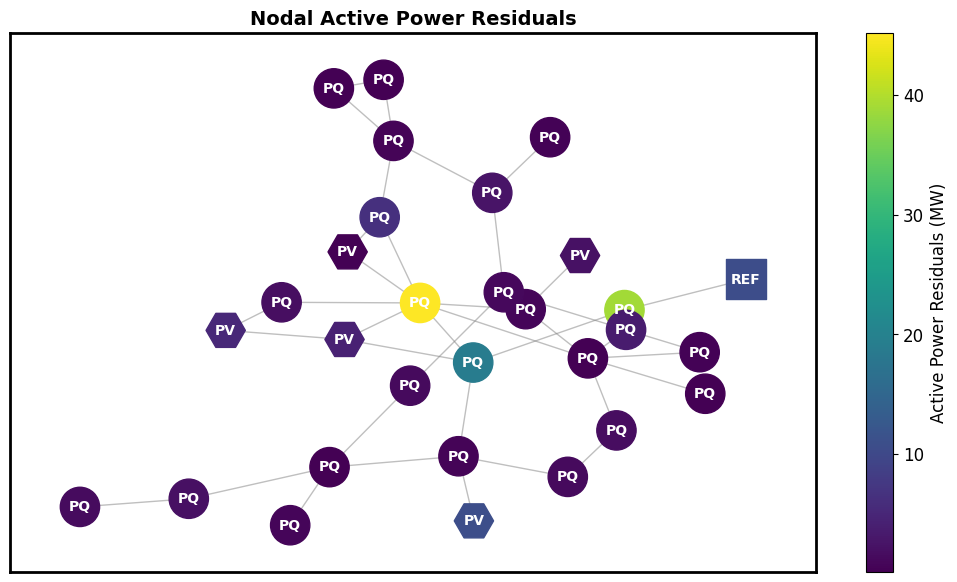

In [6]:
visualize_error(batch, output, data_module.node_normalizers[0])


## Visualize the state reconstruction capability of gridFM-v0.2 for each feature:
- Active Power Demand (MW)
- Reactive Power Demand (MVar)
- Active Power Generated (MW)
- Reactive Power Generated (MVar)
- Voltage Magnitude (p.u.)
- Voltage Angle (degrees)



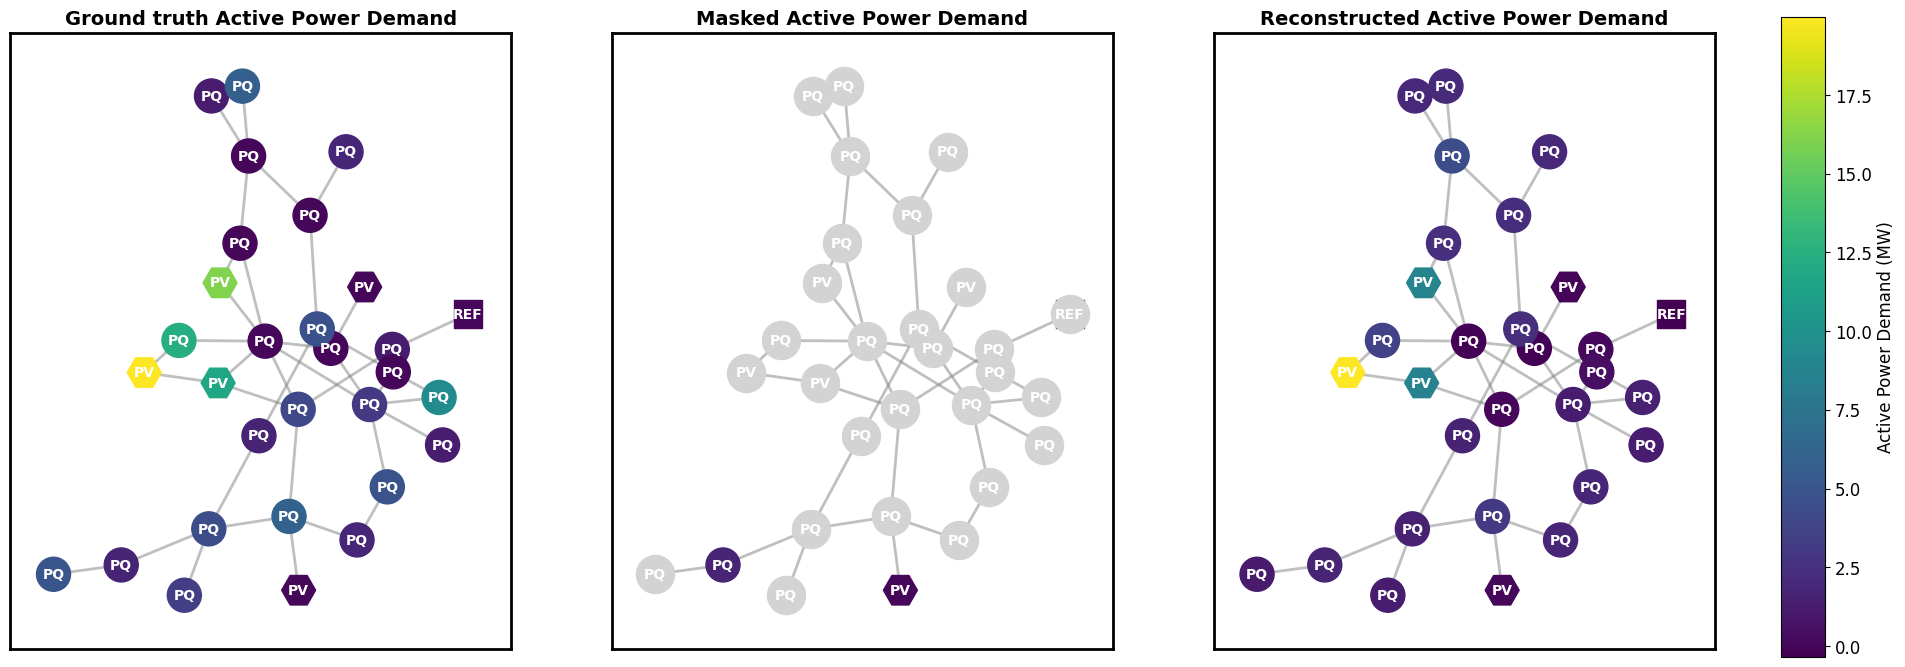

In [7]:
visualize_quantity_heatmap(
    batch,
    output,
    PD,
    "Active Power Demand",
    "MW",
    data_module.node_normalizers[0],
)

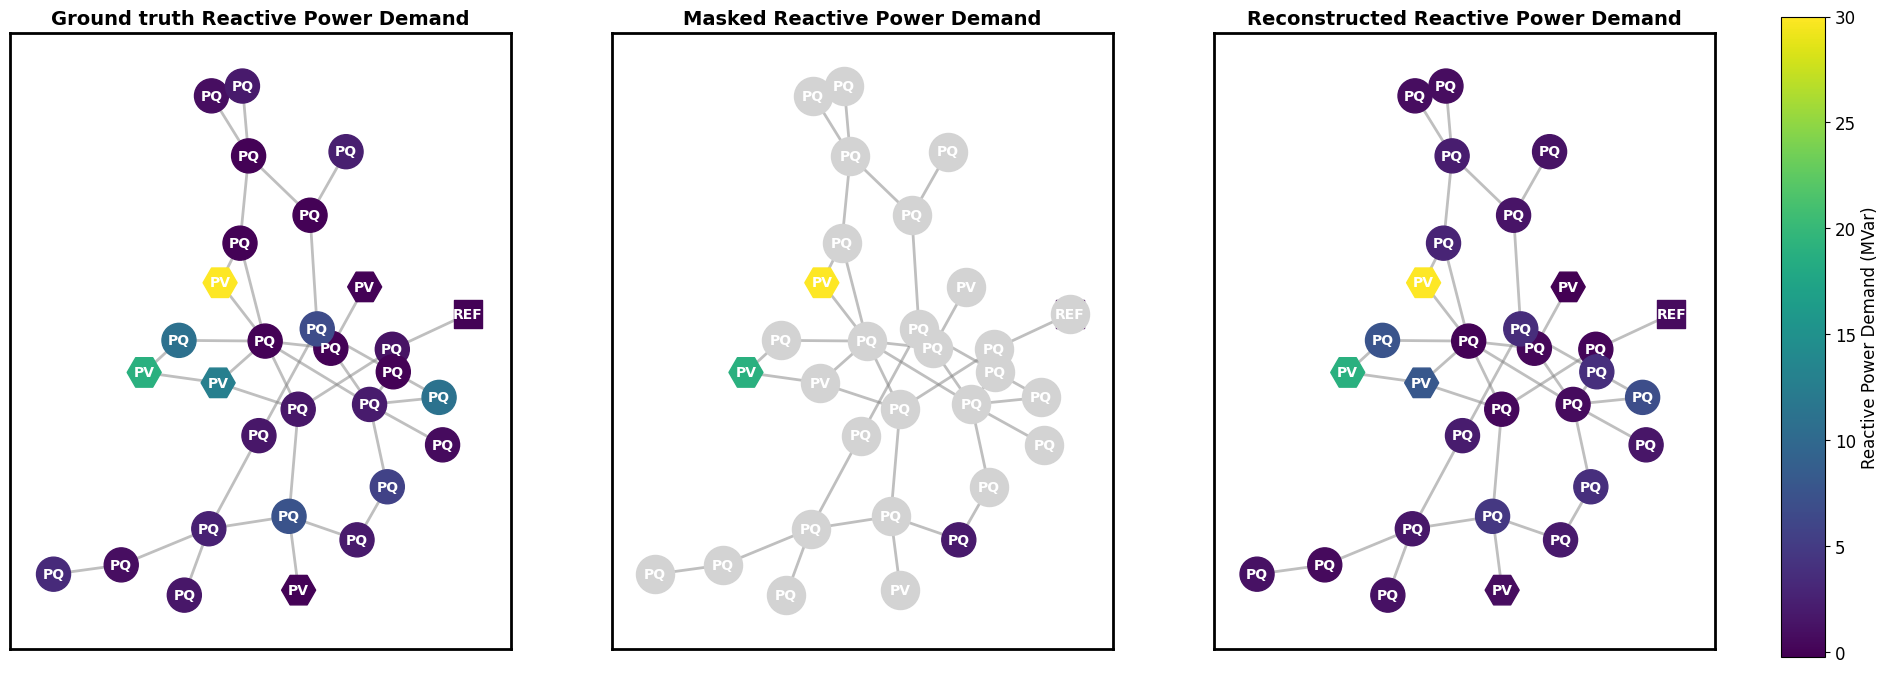

In [8]:
visualize_quantity_heatmap(
    batch,
    output,
    QD,
    "Reactive Power Demand",
    "MVar",
    data_module.node_normalizers[0],
)

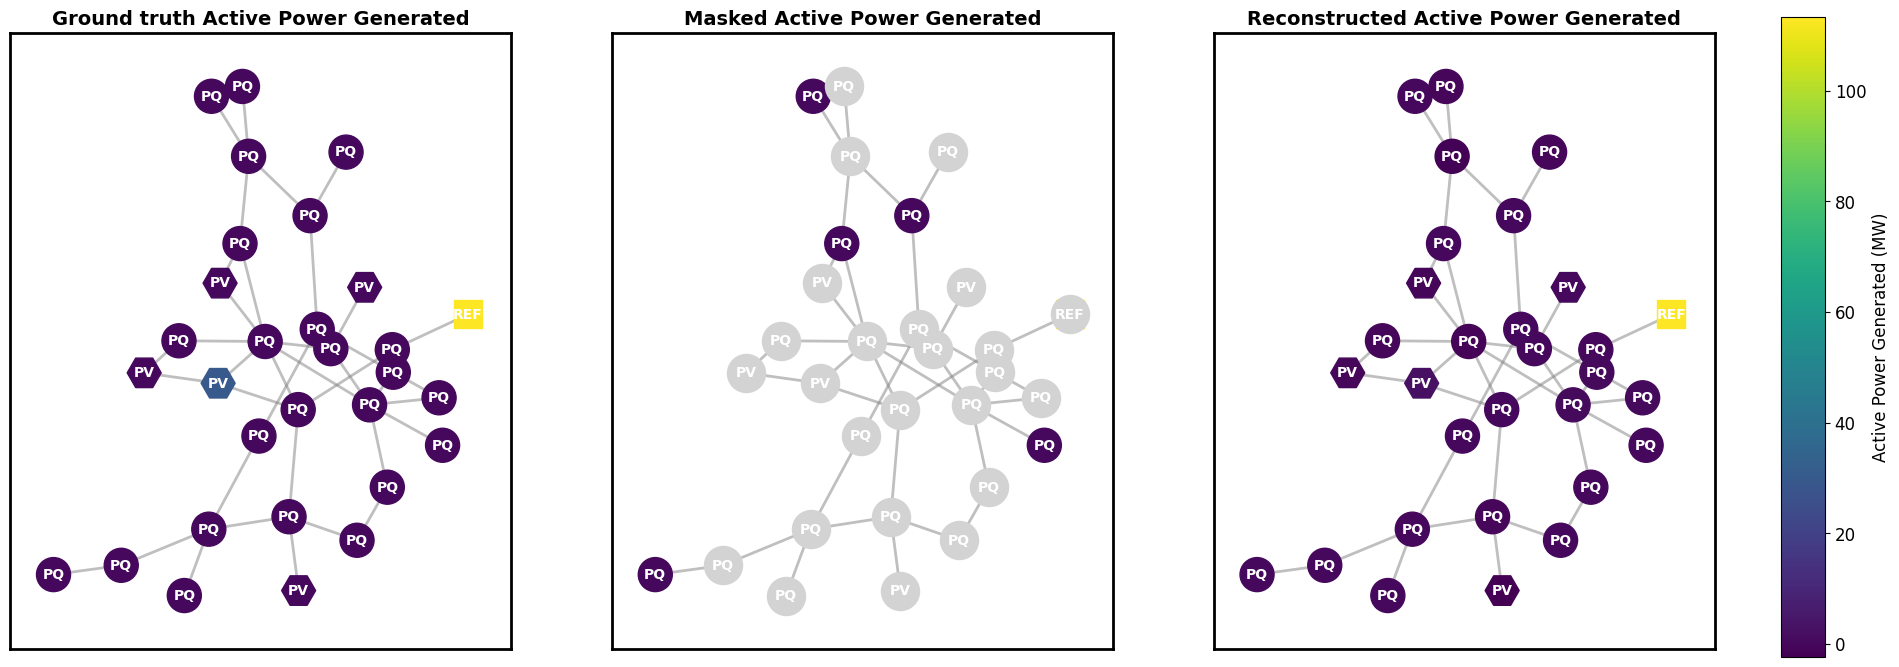

In [9]:
visualize_quantity_heatmap(
    batch,
    output,
    PG,
    "Active Power Generated",
    "MW",
    data_module.node_normalizers[0],
)

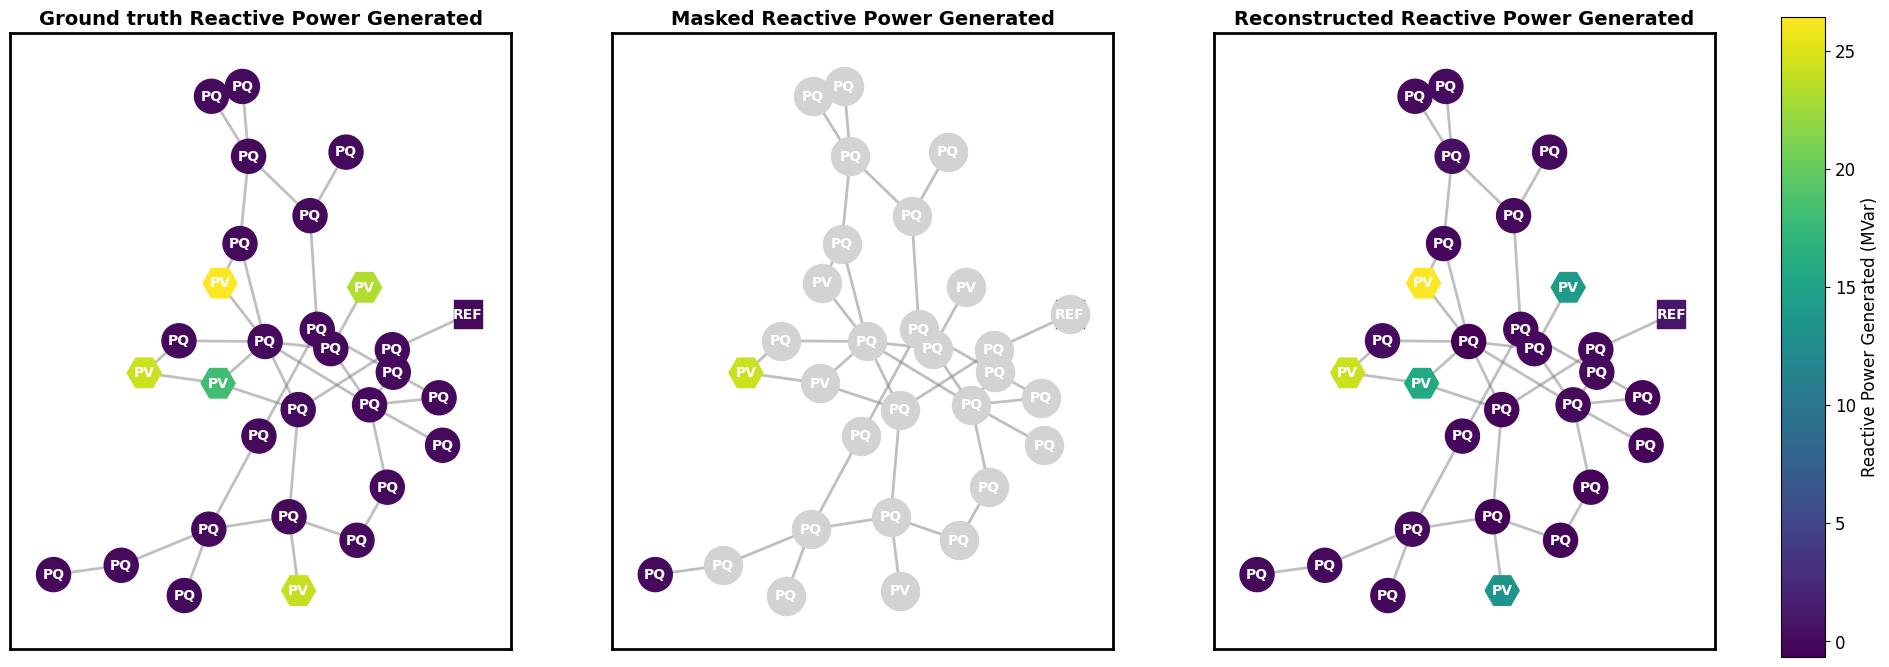

In [10]:
visualize_quantity_heatmap(
    batch,
    output,
    QG,
    "Reactive Power Generated",
    "MVar",
    data_module.node_normalizers[0],
)

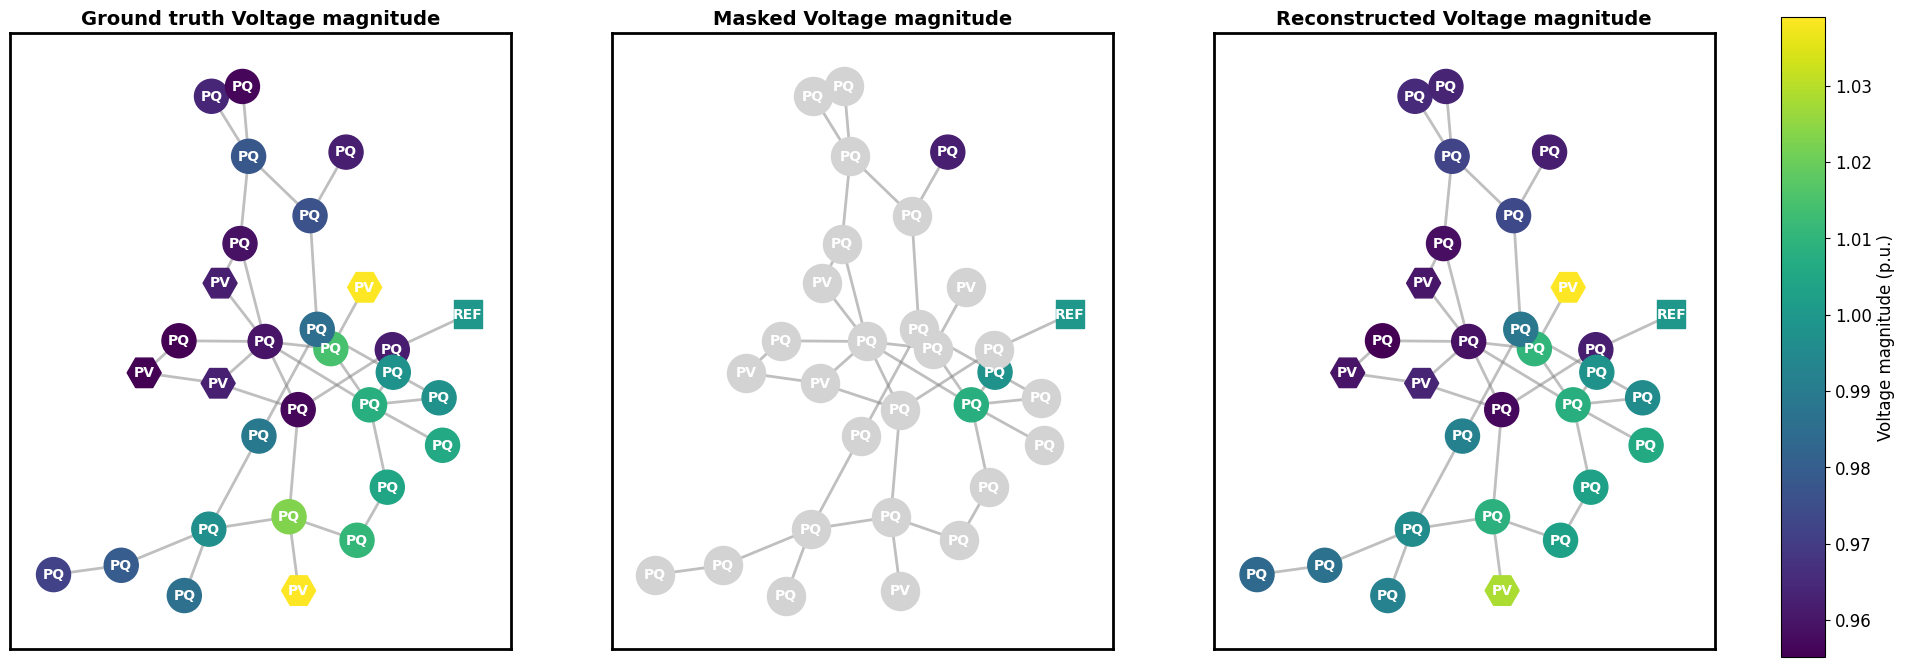

In [11]:
visualize_quantity_heatmap(
    batch,
    output,
    VM,
    "Voltage magnitude",
    "p.u.",
    data_module.node_normalizers[0],
)

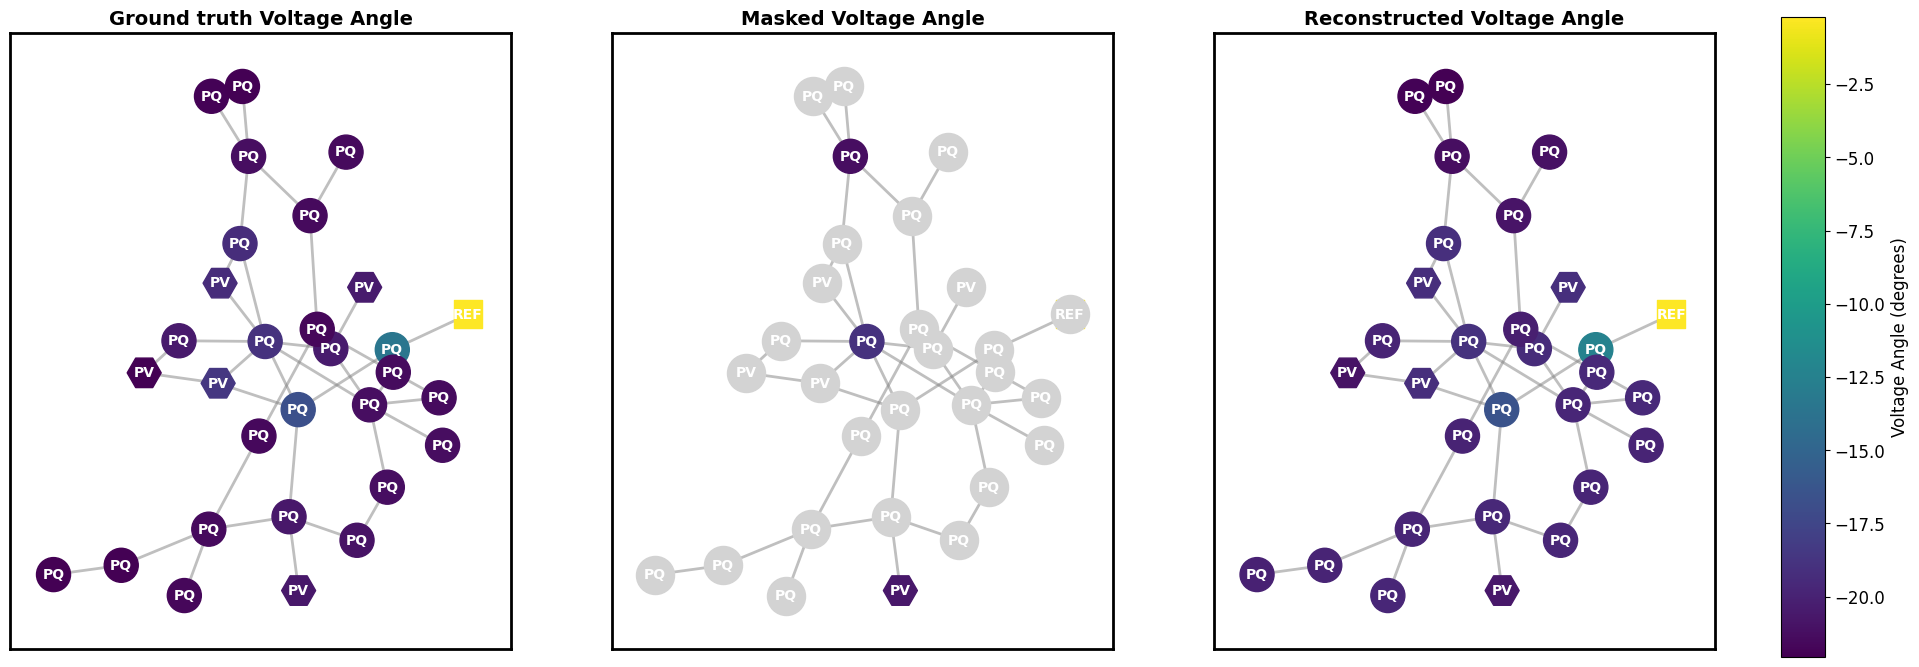

In [12]:
visualize_quantity_heatmap(
    batch, # The ground truth
    output, # The IA guess
    VA,
    "Voltage Angle",
    "degrees",
    data_module.node_normalizers[0],
)

The RMSE

In [13]:
import numpy as np
import numpy.char as char
from sklearn.metrics import mean_squared_error
from gridfm_graphkit.datasets.globals import PQ, PV, REF, PD, QD, PG, QG, VM, VA

true_denorm = model.node_normalizers[0].inverse_transform(batch.y)
y_true_np = true_denorm.detach().cpu().numpy()
pred_denom = model.node_normalizers[0].inverse_transform(output)
y_pred_np = pred_denom.detach().cpu().numpy()


In [14]:
# Ze datu hartu bariable bakoitzean
VM_true= y_true_np[:, VM][batch.mask[:, VM]]
VM_pred=y_pred_np[:, VM][batch.mask[:, VM]]
VA_true= y_true_np[:, VA][batch.mask[:, VA]]
VA_pred=y_pred_np[:, VA][batch.mask[:, VA]]
QG_true= y_true_np[:, QG][batch.mask[:, QG]]
QG_pred=y_pred_np[:, QG][batch.mask[:, QG]]
PG_true= y_true_np[:, PG][batch.mask[:, PG]]
PG_pred=y_pred_np[:, PG][batch.mask[:, PG]]

[]
# KAlkulatu RMSE
rmse_vm = np.sqrt(mean_squared_error(VM_true, VM_pred))
rmse_va = np.sqrt(mean_squared_error(VA_true, VA_pred))
rmse_qg = np.sqrt(mean_squared_error(QG_true, QG_pred))
rmse_pg = np.sqrt(mean_squared_error(PG_true, PG_pred))

print(rmse_vm, rmse_va, rmse_qg, rmse_pg)

0.008787705147755547 1.3043876805989152 3.655254521933758 7.170655522939455


NameError: name 'config_optim' is not defined